# Photoelectric Effect
### Determination of Planck's constant

A diffraction grating selects a wavelength from its angle; each wavelength has a frequency and a measured stopping voltage. Einstein's relation makes the `U_0` vs `nu` slope equal to `h/e`, so a straight-line fit yields Planck's constant.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make the physexp package importable
from physexp import photoelectric as pe, plots
from physexp.display import uframe, apply_style
apply_style()

## 1. Raw measurements

Diffraction angles and stopping voltages from `data/photoelectric.csv`.

In [2]:
raw = pe.load_measurements()
raw

,measurement,diffraction_angle_deg,stopping_voltage_V
0,1,13.5,0.70
1,2,14.0,0.73
2,3,15.0,0.72
3,4,16.5,0.62
4,5,18.0,0.52
5,6,19.0,0.48
6,7,20.0,0.47
7,8,22.0,0.44
8,9,24.0,0.45


## 2. Derived quantities

Wavelength and frequency for each angle, with propagated uncertainties.

In [3]:
result = pe.run()
uframe(
    {
        'wavelength_m': result.table['wavelength_m'],
        'frequency_Hz': result.table['frequency_Hz'],
        'stopping_voltage_V': result.table['stopping_voltage_V'],
    },
    angle_deg=result.table['angle_deg'],
)

,wavelength_m,frequency_Hz,stopping_voltage_V,angle_deg
0,(3.891+/-0.071)e-07,(7.71+/-0.14)e+14,0.700+/-0.010,13.5
1,(4.032+/-0.071)e-07,(7.44+/-0.13)e+14,0.730+/-0.010,14.0
2,(4.314+/-0.070)e-07,(6.95+/-0.11)e+14,0.720+/-0.010,15.0
3,(4.734+/-0.070)e-07,(6.333+/-0.093)e+14,0.620+/-0.010,16.5
4,(5.150+/-0.069)e-07,(5.821+/-0.078)e+14,0.520+/-0.010,18.0
5,(5.426+/-0.069)e-07,(5.525+/-0.070)e+14,0.480+/-0.010,19.0
6,(5.700+/-0.068)e-07,(5.259+/-0.063)e+14,0.470+/-0.010,20.0
7,(6.243+/-0.067)e-07,(4.802+/-0.052)e+14,0.440+/-0.010,22.0
8,(6.779+/-0.066)e-07,(4.422+/-0.043)e+14,0.450+/-0.010,24.0


## 3. Planck's constant

From the fitted `U_0` vs `nu` slope, `h = slope * e`.

In [4]:
print('Slope (h/e)       = {:.2u} V.s'.format(result.slope))
print('Planck constant h = {:.2u} J.s   (reference 6.626e-34)'.format(result.planck_constant))
print('Work function     = {:.2u} eV'.format(result.work_function_eV))

Slope (h/e)       = (1.010+/-0.031)e-15 V.s
Planck constant h = (1.618+/-0.049)e-34 J.s   (reference 6.626e-34)
Work function     = 0.039+/-0.019 eV


## 4. Figure

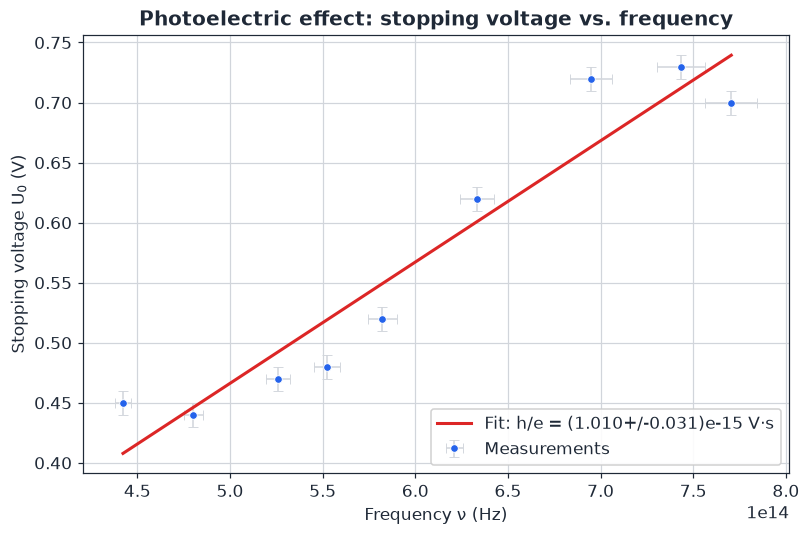

In [5]:
plots.photoelectric_fit(result);